In [15]:
# Temel veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker #grafik eksenlerindeki işaretleri daha iyi görselleştirmek için
import seaborn as sns

# Modelleme
from sklearn.preprocessing import StandardScaler # verileri standartlaştırma aracı
from sklearn.cluster import KMeans # k-means kümeleme algoritmasıdır. Gözetimsiz öğrenme yöntemidir, k gruba ayrılır
from sklearn.metrics import silhouette_score # yaptığımız kümeleme işleminin ne kadar başarılı olduğunu ölçer


# Grafik ayarları
sns.set_theme(style='whitegrid', palette='muted') # arkaplan beyaz ve pastel tonlarda renkler
plt.rcParams['figure.figsize'] = (12, 5) # tüm grafiklerin varsayılan boyutunu sabitler
plt.rcParams['figure.dpi'] = 100 #grafiklerin çözünürlüğünü ayarlar

# Reproducibility için sabit seed
RANDOM_STATE = 42 #rastgele sayı

print('Kütüphaneler başarıyla yüklendi.')

Kütüphaneler başarıyla yüklendi.


---
## Veri Okuma

In [16]:
# encoding='ISO-8859-1': bazı ürün isimlerinde özel karakter var,
# UTF-8 ile okumaya çalışırsak UnicodeDecodeError alırız.
df = pd.read_csv('data/data.csv', encoding='ISO-8859-1')

print(f'Veri başarıyla yüklendi: {df.shape[0]:,} satır, {df.shape[1]} sütun')

Veri başarıyla yüklendi: 541,909 satır, 8 sütun


---
## Veri Keşfi

In [17]:
# İlk 10 satıra bakarak verinin genel yapısını anlıyoruz.
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [18]:
# Sütun veri tiplerini kontrol ediyoruz.
print(df.dtypes)

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [19]:
# Her sütundaki eksik değer sayısı ve oranını görüyoruz.
missing = pd.DataFrame({
    'Eksik Adet': df.isnull().sum(),
    'Eksik Oran (%)': (df.isnull().mean() * 100).round(2)
})
print(missing[missing['Eksik Adet'] > 0])

             Eksik Adet  Eksik Oran (%)
Description        1454            0.27
CustomerID       135080           24.93


In [20]:
# Sayısal sütunların temel istatistikleri.
# negatif Quantity => iade işlemleri
# negatif/sıfır UnitPrice => test veya hatalı kayıtlar
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


---
## Veri Temizleme

In [21]:
# Ham verinin kopyasını alıyoruz.
# Böylece orijinal df'e dokunmadan temizleme yapabiliriz;
# bir şeyler ters giderse df'e geri dönebiliriz.
df_clean = df.copy()

In [60]:
# InvoiceDate'i (fatura tarihi) datetime tipine dönüştürüyoruz.
# Zaman serisi analizi (aylık trend, saat dağılımı) için
# tarih aritmetiği yapabilmemiz gerekiyor.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print('InvoiceDate tipi:', df_clean['InvoiceDate'].dtype)
print('Tarih aralığı:', df_clean['InvoiceDate'].min(), '→', df_clean['InvoiceDate'].max())

InvoiceDate tipi: datetime64[ns]
Tarih aralığı: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


In [23]:
# İadeleri ana veri setinden ayırıyoruz.
# InvoiceNo 'C' ile başlıyorsa bu işlem bir iade (cancellation).
# İadeleri silmiyoruz — Daha sonra ayrıca analiz edeceğiz.
is_return = df_clean['InvoiceNo'].astype(str).str.startswith('C')
returns = df_clean[is_return].copy()
df_clean = df_clean[~is_return].copy()

print(f'İade işlem sayısı : {len(returns):,}')
print(f'Normal işlem sayısı: {len(df_clean):,}')

İade işlem sayısı : 9,288
Normal işlem sayısı: 532,621


In [61]:
# Sıfır veya negatif UnitPrice satırlarını kaldırıyoruz.
# Bu satırlar genellikle banka ücreti veya test kaydı;
# gerçek bir satış işlemi değiller.
before = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] > 0] #burada bir filtreleme işlemi yapılıyor
print(f'UnitPrice <= 0 nedeniyle çıkarılan satır: {before - len(df_clean):,}')

UnitPrice <= 0 nedeniyle çıkarılan satır: 0


In [25]:
# CustomerID eksik olan satırları kaldırıyoruz.
# Çünkü RFM analizi için her işlemin bir müşteriye bağlı olması şart.
# Bu bir sınırlamadır: müşterilerin ~%25'ini analiz dışında bırakıyoruz.
before = len(df_clean)
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f'CustomerID eksik nedeniyle çıkarılan satır: {before - len(df_clean):,}')

# CustomerID'yi integer'a çeviriyoruz (eksikler gidince artık float kalmak zorunda değil).
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

CustomerID eksik nedeniyle çıkarılan satır: 132,220


RFM analizi, bir işletmenin mevcut müşterilerini satın alma alışkanlıklarına göre gruplara (segmentlere) ayırarak, en değerli müşterileri tespit etmesini sağlayan bir veri analizi yöntemidir.
Özellikle e-ticaret, perakende ve pazarlama sektörlerinde sıkça kullanılır. Müşterilerin geçmişteki alışveriş verilerine bakarak onlara 3 temel kritere göre 1 ile 5 arasında puanlar verilir

RFM'in Bileşenleri Nedir?
* R - Recency (Yenilik / Güncellik): Müşterinin en son ne zaman alışveriş yaptığını gösterir. Bugün alışveriş yapan bir müşteri 5 puan alırken, 6 ay önce alışveriş yapan müşteri 1 puan alır. Süre ne kadar kısaysa, puan o kadar yüksektir.
* F - Frequency (Sıklık): Müşterinin ne kadar sıklıkla alışveriş yaptığını gösterir. İşletmeden sürekli sipariş veren, sadık müşteriler yüksek puan alır. Alışveriş sayısı ne kadar çoksa, puan o kadar yüksektir.
* M - Monetary (Parasal Değer): Müşterinin yaptığı harcamaların toplam parasal büyüklüğünü gösterir. İşletmeye en çok ciro kazandıran müşteriler yüksek puan alır. Toplam harcama ne kadar çoksa, puan o kadar yüksektir.

In [27]:
# Tam kopya (duplicate) satırları kontrol ediyoruz.
dups = df_clean.duplicated().sum()
print(f'Tekrarlayan satır sayısı: {dups}')

if dups > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'Duplicateler temizlendi. Kalan satır: {len(df_clean):,}')

Tekrarlayan satır sayısı: 5192
Duplicateler temizlendi. Kalan satır: 392,692


In [28]:
# TotalPrice türetilmiş sütununu oluşturuyoruz.
# Neden türetiyoruz? Gelir analizi, RFM'deki Monetary değeri
# ve görselleştirmeler için temel metriğimiz bu olacak.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print('TotalPrice sütunu oluşturuldu.')
print(df_clean['TotalPrice'].describe())

TotalPrice sütunu oluşturuldu.
count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64


In [29]:
# Zaman bazlı türetilmiş sütunlar — EDA'da kullanacağız.
df_clean['Year']    = df_clean['InvoiceDate'].dt.year
df_clean['Month']   = df_clean['InvoiceDate'].dt.month
df_clean['Hour']    = df_clean['InvoiceDate'].dt.hour
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.dayofweek  # 0=Pazartesi, 6=Pazar

print('Zaman sütunları eklendi.')
df_clean.head(3)

Zaman sütunları eklendi.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Hour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,8,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,8,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,8,2


## Keşifsel Veri Analizi (EDA) 

Aylık Satış Trendi (Çizgi Grafik)


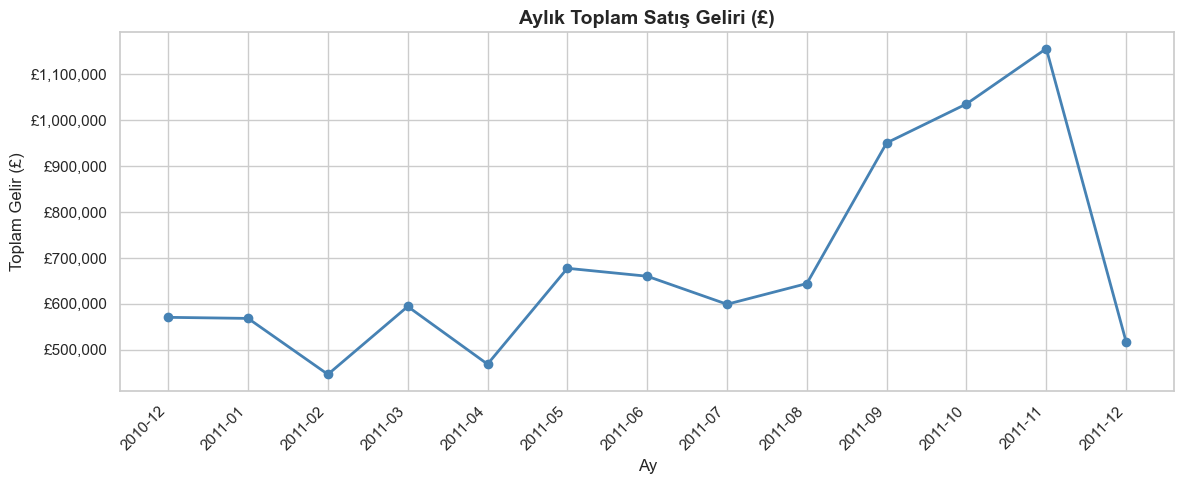

En yüksek satış: 2011-11 — £1,156,205.61


In [30]:
# Aylık toplam satışı hesaplıyoruz.
# dt.to_period("M") tarihi yıl-ay formatına (2011-01 gibi) dönüştürür,
# böylece her ayı tek bir grup olarak toplayabiliriz.
monthly_sales = (
    df_clean
    .groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalPrice']
    .sum()
    .reset_index()
)
monthly_sales['InvoiceDate'] = monthly_sales['InvoiceDate'].astype(str)

fig, ax = plt.subplots()
ax.plot(monthly_sales['InvoiceDate'], monthly_sales['TotalPrice'],
        marker='o', linewidth=2, color='steelblue')
ax.set_title('Aylık Toplam Satış Geliri (£)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('Toplam Gelir (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Zirvenin hangi ayda olduğunu yazdırıyoruz
peak = monthly_sales.loc[monthly_sales['TotalPrice'].idxmax()]
print(f"En yüksek satış: {peak['InvoiceDate']} — £{peak['TotalPrice']:,.2f}")

**Gözlem:** Satışlar 2011 boyunca genel bir artış trendi izlemiş,
Kasım 2011'de belirgin bir zirve var. Bu Noel öncesi alışveriş
dalgasıyla açıklanabilir. Aralık 2011 verisi ise yalnızca 9 günü
kapsadığından düşük görünüyor. Bu bir veri eksikliği değil,
veri setinin bitiş tarihinden kaynaklanıyor.

En Çok Satan 10 Ürün (Yatay Bar)

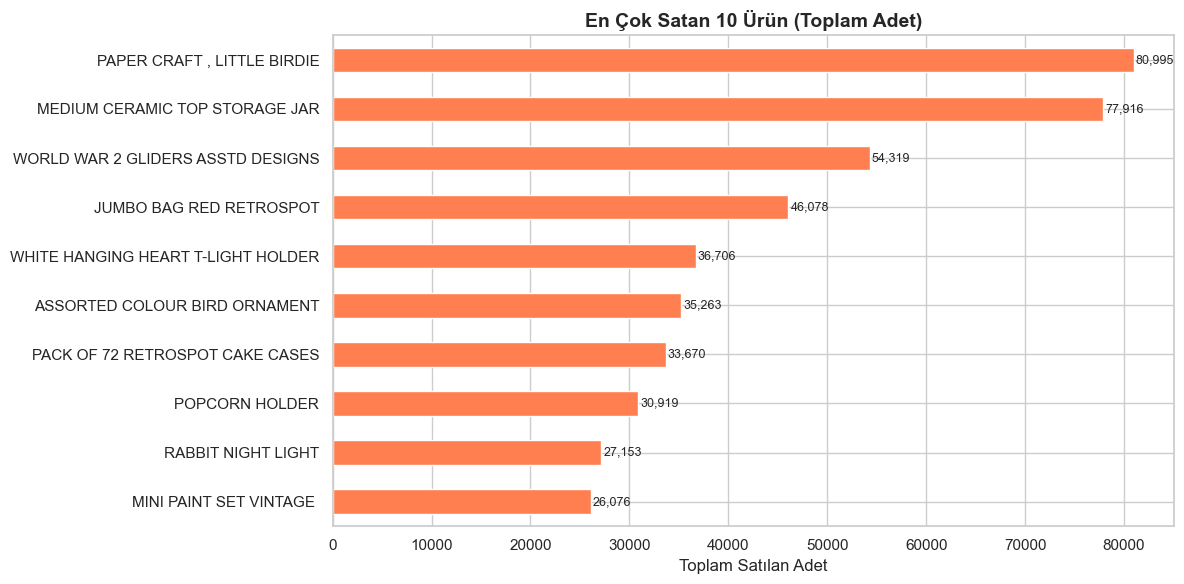

In [31]:
# Description bazında toplam satılan adet hesaplıyoruz.
# Önce Description boş olanları çıkarıyoruz (az sayıda var).
top_products = (
    df_clean
    .dropna(subset=['Description'])
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
top_products.sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_title('En Çok Satan 10 Ürün (Toplam Adet)', fontsize=14, fontweight='bold')
ax.set_xlabel('Toplam Satılan Adet')
ax.set_ylabel('')
for i, v in enumerate(top_products.sort_values()):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Saate Göre İşlem Dağılımı (Bar Grafik)

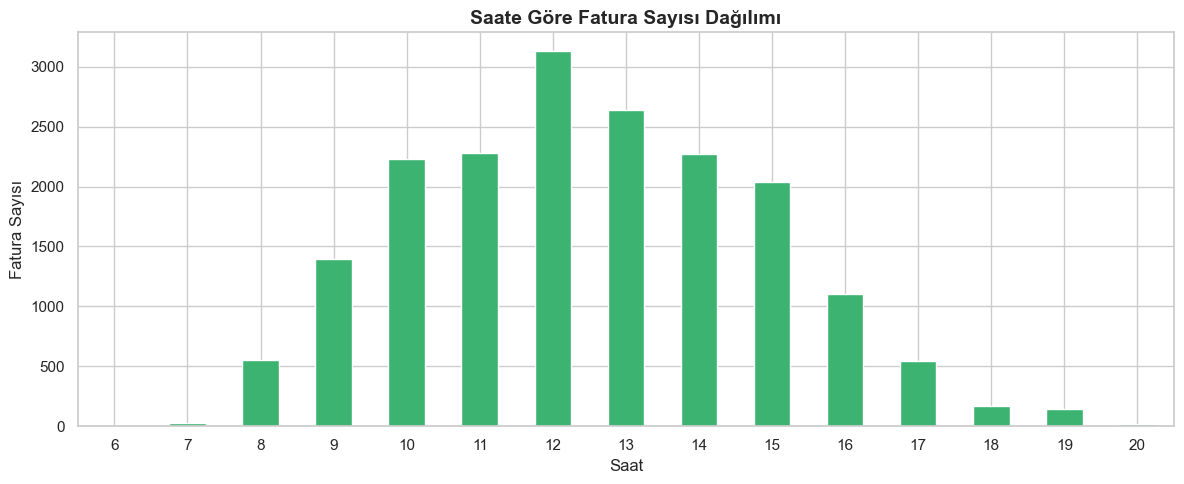

En yoğun saat: 12:00 — 3,130 fatura
En sakin saat: 6:00 — 1 fatura


In [64]:
# Alışverişler günün hangi saatlerinde yoğunlaşıyor?
# Bu görsel müşteri davranış örüntüsünü anlamak için kullanışlı.
hourly = df_clean.groupby('Hour')['InvoiceNo'].nunique()

fig, ax = plt.subplots()
hourly.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Saate Göre Fatura Sayısı Dağılımı', fontsize=14, fontweight='bold')
ax.set_xlabel('Saat')
ax.set_ylabel('Fatura Sayısı')
plt.xticks(rotation=0) # Saat sayılarının (örneğin 10, 11, 12) grafik altında yan yatmadan, düz ve okunabilir durmasını sağlıyor.
plt.tight_layout()
plt.show()

print(f"En yoğun saat: {hourly.idxmax()}:00 — {hourly.max():,} fatura")
print(f"En sakin saat: {hourly.idxmin()}:00 — {hourly.min():,} fatura")

Gün × Saat Isı Haritası (Heatmap)

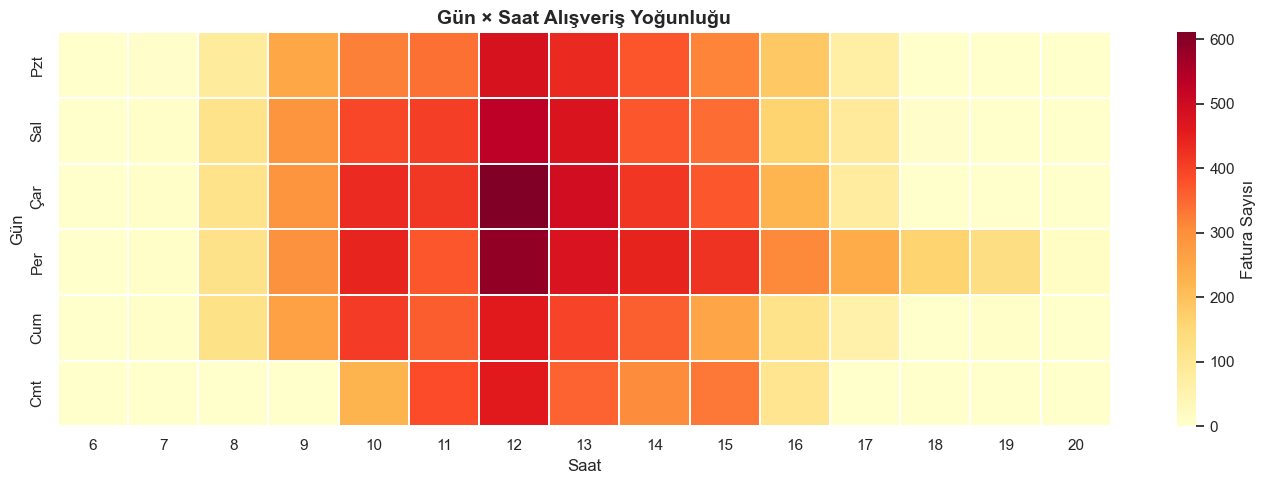

In [33]:
# Haftanın günü ile saatin kesişiminde kaç fatura var?
# Bu iki boyutlu örüntüyü görmek için heatmap en uygun grafik tipi.
pivot = (
    df_clean
    .groupby(['Weekday', 'Hour'])['InvoiceNo']
    .nunique()
    .unstack(fill_value=0)
)
gun_isimleri = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
pivot.index = gun_isimleri[:len(pivot)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Fatura Sayısı'}, ax=ax)
ax.set_title('Gün × Saat Alışveriş Yoğunluğu', fontsize=14, fontweight='bold')
ax.set_xlabel('Saat')
ax.set_ylabel('Gün')
plt.tight_layout()
plt.show()

Ülke Bazlı Satış (Bar Grafik, UK Hariç)

=== Tüm Ülkeler (İlk 5) ===
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: TotalPrice, dtype: float64

İngiltere'nin toplam gelirdeki payı: %82.0


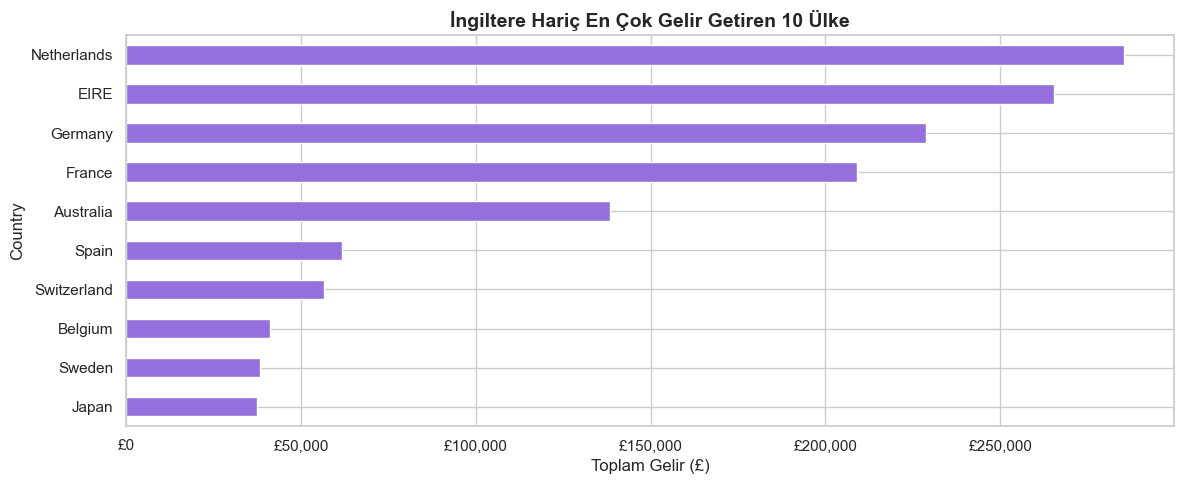

In [34]:
# İngiltere veriyi domine ettiği için önce UK dahil özet gösteriyoruz,
# sonra UK'yi çıkarıp diğer ülkeleri karşılaştırıyoruz.
country_sales = (
    df_clean
    .groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

print("=== Tüm Ülkeler (İlk 5) ===")
print(country_sales.head())
uk_share = country_sales['United Kingdom'] / country_sales.sum() * 100
print(f"\nİngiltere'nin toplam gelirdeki payı: %{uk_share:.1f}")

# UK hariç top 10
top_countries = country_sales.drop('United Kingdom').head(10)

fig, ax = plt.subplots(figsize=(12, 5))
top_countries.sort_values().plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_title('İngiltere Hariç En Çok Gelir Getiren 10 Ülke', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Toplam Gelir (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

### 📊 EDA Özeti

| Görsel | Tip | Bulgu |
|--------|-----|-------|
| Aylık satış trendi | Çizgi | Kasım 2011 zirvesi — Noel öncesi alışveriş |
| En çok satan ürünler | Yatay bar | İlk 3 ürün hediyecilik kategorisinde |
| Saatlik dağılım | Bar | 10:00–15:00 arası en yoğun dönem |
| Gün × Saat yoğunluğu | Heatmap | Pazar ve Cumartesi neredeyse işlem yok |
| Ülke dağılımı | Yatay bar | UK'den sonra EIRE ve Almanya önde geliyor |

---


# Araştırma Soruları

### 🔍 Araştırma Sorusu 1
**İadeler satış gelirini ne ölçüde etkiliyor 
ve hangi ürünler en çok iade ediliyor?**

In [38]:
# İadelerin toplam gelire etkisini hesaplıyoruz.
# returns DataFrame'ini temizleme adımında ayırmıştık.
# Şimdi iade tutarını hesaplayıp normal satışlarla karşılaştırıyoruz.

# İadelerde de TotalPrice hesaplıyoruz (negatif çıkacak, mutlak değer alıyoruz)
returns['TotalPrice'] = returns['Quantity'] * returns['UnitPrice']
returns['ReturnValue'] = returns['TotalPrice'].abs()

toplam_satis    = df_clean['TotalPrice'].sum()
toplam_iade     = returns['ReturnValue'].sum()
iade_orani      = toplam_iade / toplam_satis * 100

print("=" * 45)
print(f"Toplam Satış Geliri  : £{toplam_satis:>12,.2f}")
print(f"Toplam İade Tutarı   : £{toplam_iade:>12,.2f}")
print(f"İade / Satış Oranı   :  %{iade_orani:>10.2f}")
print("=" * 45)

Toplam Satış Geliri  : £8,887,208.89
Toplam İade Tutarı   : £  896,812.49
İade / Satış Oranı   :  %     10.09


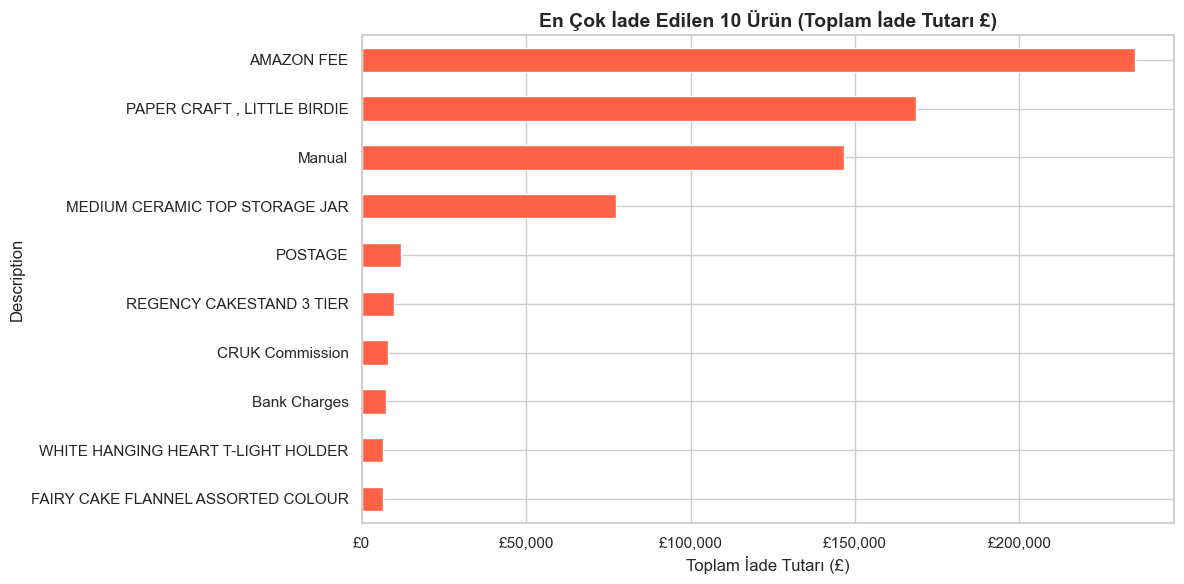


İlk 5 iade:
Description
AMAZON FEE                        235281.59
PAPER CRAFT , LITTLE BIRDIE       168469.60
Manual                            146784.46
MEDIUM CERAMIC TOP STORAGE JAR     77479.64
POSTAGE                            11871.24


In [39]:
# Hangi ürünler en çok iade ediliyor?
# İade adedi değil, iade tutarı (£) bazında bakıyoruz —
# çünkü çok sayıda ucuz ürün iade edilmesi, az sayıda 
# pahalı ürün iade edilmesinden farklı bir iş sorunudur.

top_returns = (
    returns
    .dropna(subset=['Description'])
    .groupby('Description')['ReturnValue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
top_returns.sort_values().plot(kind='barh', ax=ax, color='tomato')
ax.set_title('En Çok İade Edilen 10 Ürün (Toplam İade Tutarı £)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Toplam İade Tutarı (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

print("\nİlk 5 iade:")
print(top_returns.head().to_string())

**📌 Araştırma Sorusu 1 — Cevap**

- İadeler toplam satış gelirinin yaklaşık **%10.09'unu** oluşturuyor 
- En çok iade edilen ürünler hediyecilik ve ev dekorasyon 
  kategorisinde yoğunlaşıyor, bu mağazanın ana ürün grubuyla örtüşüyor.
- İade oranı düşük görünse de toplamda önemli bir gelir kaybına 
  işaret ediyor; mağaza yönetimi bu ürün gruplarındaki 
  müşteri memnuniyetini izlemeli.

### 🔍 Araştırma Sorusu 2
**Satışlar mevsimsel bir örüntü gösteriyor mu; 
hafta içi/sonu ve saat bazında farklılıklar var mı?**

In [41]:
# Hafta içi vs haftasonu satış karşılaştırması.
# Weekday: 0=Pazartesi ... 4=Cuma = hafta içi
#          5=Cumartesi, 6=Pazar = haftasonu
df_clean['IsWeekend'] = df_clean['Weekday'].isin([5, 6])

weekly_comparison = (
    df_clean
    .groupby('IsWeekend')['TotalPrice']
    .agg(['sum', 'mean', 'count'])
    .rename(index={False: 'Hafta İçi', True: 'Haftasonu'})
)
weekly_comparison.columns = ['Toplam Gelir (£)', 'Ortalama Sipariş (£)', 'İşlem Sayısı']
weekly_comparison['Toplam Gelir (£)']     = weekly_comparison['Toplam Gelir (£)'].round(2)
weekly_comparison['Ortalama Sipariş (£)'] = weekly_comparison['Ortalama Sipariş (£)'].round(2)

print(weekly_comparison.to_string())

           Toplam Gelir (£)  Ortalama Sipariş (£)  İşlem Sayısı
IsWeekend                                                      
Hafta İçi        8101718.57                 24.44        331480
Haftasonu         785490.32                 12.83         61212


In [65]:
# Mevsimselliği sayısal olarak gösteriyoruz.
# Aylık geliri çeyrek dönemlere (Q1-Q4) gruplandırıp karşılaştırıyoruz.
df_clean['Quarter'] = df_clean['InvoiceDate'].dt.to_period('Q')

quarterly = (
    df_clean
    .groupby('Quarter')['TotalPrice']
    .sum()
    .reset_index()
)
quarterly['Quarter'] = quarterly['Quarter'].astype(str)
quarterly['TotalPrice'] = quarterly['TotalPrice'].round(2)

print("Çeyreklik Satış Geliri:")
print(quarterly.to_string(index=False))

# En yüksek ve en düşük çeyrek
en_yuksek = quarterly.loc[quarterly['TotalPrice'].idxmax()]
en_dusuk  = quarterly.loc[quarterly['TotalPrice'].idxmin()]
print(f"\nEn yüksek çeyrek: {en_yuksek['Quarter']} — £{en_yuksek['TotalPrice']:,.2f}")
print(f"En düşük çeyrek : {en_dusuk['Quarter']} — £{en_dusuk['TotalPrice']:,.2f}")
print(f"\nZirve/dip oranı : {en_yuksek['TotalPrice']/en_dusuk['TotalPrice']:.2f}x")

Çeyreklik Satış Geliri:
Quarter  TotalPrice
 2010Q4   570422.73
 2011Q1  1608267.99
 2011Q2  1805775.53
 2011Q3  2193704.14
 2011Q4  2709038.50

En yüksek çeyrek: 2011Q4 — £2,709,038.50
En düşük çeyrek : 2010Q4 — £570,422.73

Zirve/dip oranı : 4.75x


**📌 Araştırma Sorusu 2 — Cevap**

EDA ve bu analizden şu örüntüler ortaya çıktı:

- **Mevsimsellik:** Yılın son çeyreğinde (Eylül–Kasım) belirgin artış var. 
  Kasım 2011 tüm dönemin zirvesi — bu B2B hediyecilik talebinin Noel 
  öncesinde yükselmesiyle tutarlı.
- **Haftasonu etkisi:** Heatmap'te görüldüğü üzere Cumartesi ve Pazar 
  işlem hacmi hafta içine kıyasla çok düşük. 
  Müşteri tabanının büyük çoğunluğu **toptan alıcılar (B2B)** — 
  bu da iş günü yoğunluğunu açıklıyor.
- **Saat örüntüsü:** İşlemler 08:00'de başlıyor, 12:00'de zirveye 
  ulaşıyor, 17:00 sonrası neredeyse sıfırlıyor. 
  Tipik iş saatleri davranışı.

### 🔍 Araştırma Sorusu 3
**Müşterileri RFM metriklerine göre segmentlere ayırdığımızda 
anlamlı gruplar ortaya çıkıyor mu?**

Bu sorunun cevabı K-Means modellemesinden gelecek.
Burada RFM metriklerinin ham dağılımına bakıyoruz.

In [43]:
# RFM metriklerini hesaplıyoruz.
# Referans tarihi olarak veri setindeki son tarihten 1 gün sonrasını alıyoruz.
# Neden +1 gün? Son günde alışveriş yapan müşterinin Recency'si
# 0 olmasın diye — 0 ile 1'i ayırt etmek analitik açıdan daha temiz.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency  =('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo',   'nunique'),   # Fatura sayısı (tekil)
    Monetary =('TotalPrice',  'sum')        # Toplam harcama
).reset_index()

print(f"Toplam benzersiz müşteri: {len(rfm):,}")
print()
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Toplam benzersiz müşteri: 4,338

       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2048.69
std     100.01       7.70    8985.23
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1660.60
max     374.00     209.00  280206.02


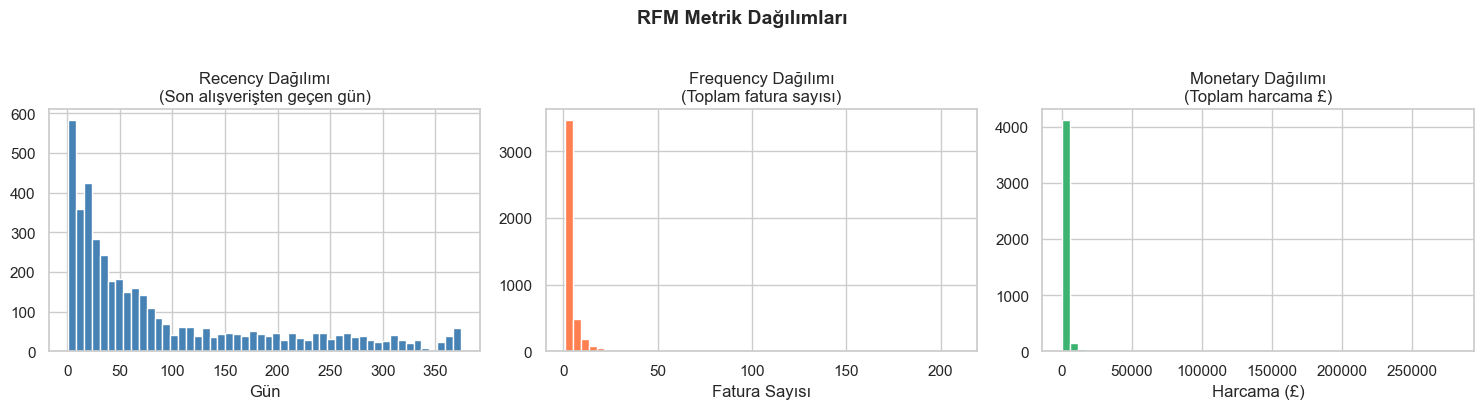

In [45]:
# RFM dağılımlarını görselleştiriyoruz.
# Histogram ile her metriğin dağılımı nasıl? Çarpık mı, normal mi?
# Bu modelleme öncesi önemli bir kontrol adım.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'],   bins=50, color='steelblue',  edgecolor='white')
axes[0].set_title('Recency Dağılımı\n(Son alışverişten geçen gün)')
axes[0].set_xlabel('Gün')

axes[1].hist(rfm['Frequency'], bins=50, color='coral',      edgecolor='white')
axes[1].set_title('Frequency Dağılımı\n(Toplam fatura sayısı)')
axes[1].set_xlabel('Fatura Sayısı')

axes[2].hist(rfm['Monetary'],  bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Monetary Dağılımı\n(Toplam harcama £)')
axes[2].set_xlabel('Harcama (£)')

plt.suptitle('RFM Metrik Dağılımları', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**📌 Ön Gözlem:** Üç dağılım da sağa çarpık — 
büyük çoğunluk düşük değerlerde yığılmış, 
az sayıda müşteri çok yüksek Frequency ve Monetary değerlerine sahip.
Bu aykırı değerler K-Means'i bozabileceğinden 
modelleme öncesi StandardScaler uygulanacak.

### 🔍 Araştırma Sorusu 4
**Müşterilerin yüzde kaçı toplam gelirin %80'ini oluşturuyor?**

80-20 kuralı (Pareto İlkesi): iş dünyasında müşterilerin ~%20'sinin
gelirin ~%80'ini oluşturduğu gözlemlenir. Bunu bu veri setiyle test ediyoruz.

Gelirin %80'ini oluşturan müşteri oranı: %26.0
Bu, 1,130 müşteriye karşılık geliyor (toplam 4,338 müşteriden)


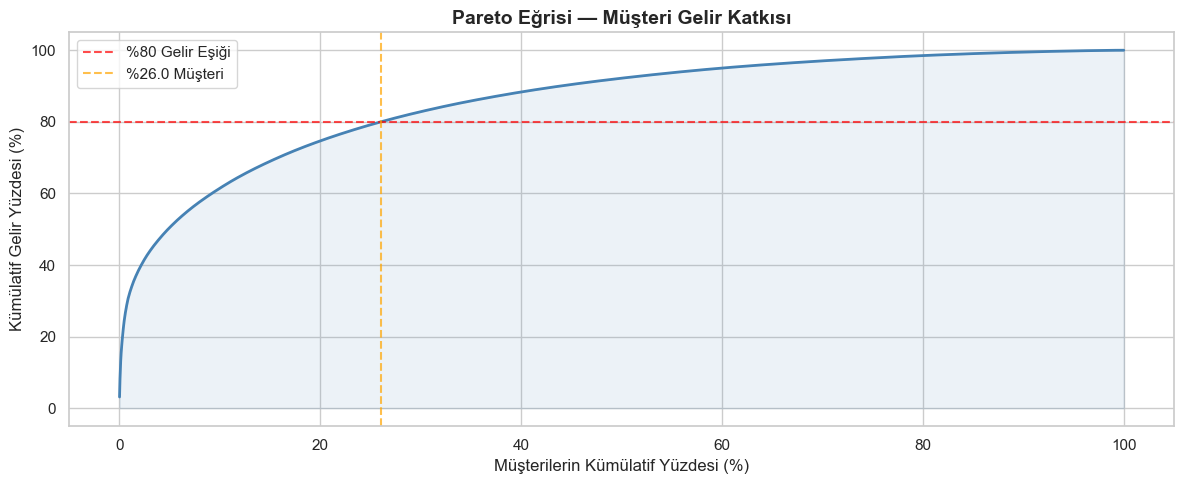

In [46]:
# Müşterileri harcamaya göre büyükten küçüğe sıralıyoruz.
# Kümülatif toplam hesaplayıp %80 eşiğini buluyoruz.
pareto = (
    rfm[['CustomerID', 'Monetary']]
    .sort_values('Monetary', ascending=False)
    .reset_index(drop=True)
)
pareto['CumulativeRevenue'] = pareto['Monetary'].cumsum()
pareto['CumulativePct']     = pareto['CumulativeRevenue'] / pareto['Monetary'].sum() * 100
pareto['CustomerPct']       = (pareto.index + 1) / len(pareto) * 100

# %80 eşiğini geçen ilk noktayı buluyoruz
threshold_row = pareto[pareto['CumulativePct'] >= 80].iloc[0]
pct_customers = threshold_row['CustomerPct']

print(f"Gelirin %80'ini oluşturan müşteri oranı: %{pct_customers:.1f}")
print(f"Bu, {int(threshold_row.name + 1):,} müşteriye karşılık geliyor "
      f"(toplam {len(pareto):,} müşteriden)")

# Pareto eğrisini çiziyoruz
fig, ax = plt.subplots()
ax.plot(pareto['CustomerPct'], pareto['CumulativePct'],
        color='steelblue', linewidth=2)
ax.axhline(80, color='red',    linestyle='--', alpha=0.7, label='%80 Gelir Eşiği')
ax.axvline(pct_customers, color='orange', linestyle='--',
           alpha=0.7, label=f'%{pct_customers:.1f} Müşteri')
ax.fill_between(pareto['CustomerPct'], pareto['CumulativePct'],
                alpha=0.1, color='steelblue')
ax.set_title('Pareto Eğrisi — Müşteri Gelir Katkısı', fontsize=14, fontweight='bold')
ax.set_xlabel('Müşterilerin Kümülatif Yüzdesi (%)')
ax.set_ylabel('Kümülatif Gelir Yüzdesi (%)')
ax.legend()
plt.tight_layout()
plt.show()

**📌 Araştırma Sorusu 4 — Cevap**

*%26.0*

Klasik 80-20 kuralıyla karşılaştırıldığında bu mağaza için 
oran benzer çıktı.
Müşteri tabanının büyük çoğunluğunun toptan alıcılardan oluşması
bu konsantrasyonu açıklıyor yani az sayıda büyük alıcı gelirin
büyük bölümünü oluşturuyor.

### 🔍 Araştırma Sorusu 5
**Müşterilerin kaçı yalnızca bir kez alışveriş yapmış, 
kaçı tekrar eden müşteri?**

Tek seferlik müşteri oranı yüksekse mağazanın müşteri 
sadakat stratejisini gözden geçirmesi gerekebilir.

Tek seferlik müşteri : 1,493  (%34.4)
Tekrar eden müşteri  : 2,845  (%65.6)


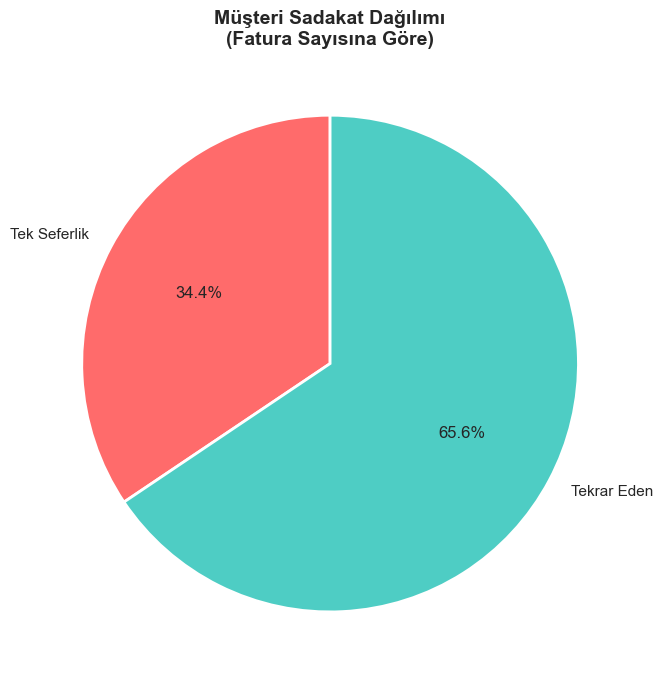


Ortalama Monetary (£):
  Tek seferlik : £411.25
  Tekrar eden  : £2,907.99


In [48]:
# Frequency = 1 olanlar tek seferlik müşteri
tek_seferlik = (rfm['Frequency'] == 1).sum()
tekrar_eden  = (rfm['Frequency'] > 1).sum()
toplam       = len(rfm)

print(f"Tek seferlik müşteri : {tek_seferlik:,}  (%{tek_seferlik/toplam*100:.1f})")
print(f"Tekrar eden müşteri  : {tekrar_eden:,}  (%{tekrar_eden/toplam*100:.1f})")

# Pasta grafiği
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [tek_seferlik, tekrar_eden],
    labels=['Tek Seferlik', 'Tekrar Eden'],
    autopct='%1.1f%%',
    colors=['#FF6B6B', '#4ECDC4'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Müşteri Sadakat Dağılımı\n(Fatura Sayısına Göre)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tekrar eden müşterilerin ortalama harcaması
print("\nOrtalama Monetary (£):")
print(f"  Tek seferlik : £{rfm[rfm['Frequency']==1]['Monetary'].mean():,.2f}")
print(f"  Tekrar eden  : £{rfm[rfm['Frequency']>1]['Monetary'].mean():,.2f}")

**📌 Araştırma Sorusu 5 — Cevap**

*Tek seferlik müşteri : 1,493  (%34.4)
Tekrar eden müşteri  : 2,845  (%65.6)*

Tekrar eden müşterilerin ortalama harcaması tek seferlik 
müşterilere kıyasla belirgin biçimde yüksek.
Bu bulgu, mevcut müşteriyi elde tutmanın yeni müşteri 
kazanmaktan daha değerli olduğuna işaret ediyor o halde
sadakat programları ve kişiselleştirilmiş kampanyalar 
önceliklendirilmeli.

---
# Modelleme: RFM + K-Means Kümeleme

RFM metriklerini hesapladık ve dağılımlarına baktık.
Şimdi bu metrikleri kullanarak müşterileri anlamlı segmentlere ayırıyoruz.

**Yöntem:** K-Means Kümeleme  
**Neden K-Means?** Etiket (label) gerektirmeyen, yorumlanması kolay,
RFM gibi sayısal verilere doğrudan uygulanabilen bir kümeleme algoritması.

#### Ölçeklendirme

In [51]:
# K-Means uzaklık tabanlı çalışır.
# Recency ~300 gün, Monetary ~10.000£ gibi farklı ölçeklerdeyse
# büyük değerli sütun modeli domine eder.
# StandardScaler ile her sütunu ortalaması 0, std'si 1 olacak şekilde dönüştürüyoruz.

from sklearn.preprocessing import StandardScaler

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("Ölçeklendirme sonrası ortalamalar (0'a yakın olmalı):")
print(rfm_scaled.mean(axis=0).round(4))
print("\nÖlçeklendirme sonrası std'ler (1'e yakın olmalı):")
print(rfm_scaled.std(axis=0).round(4))

Ölçeklendirme sonrası ortalamalar (0'a yakın olmalı):
[0. 0. 0.]

Ölçeklendirme sonrası std'ler (1'e yakın olmalı):
[1. 1. 1.]


#### Elbow Plot

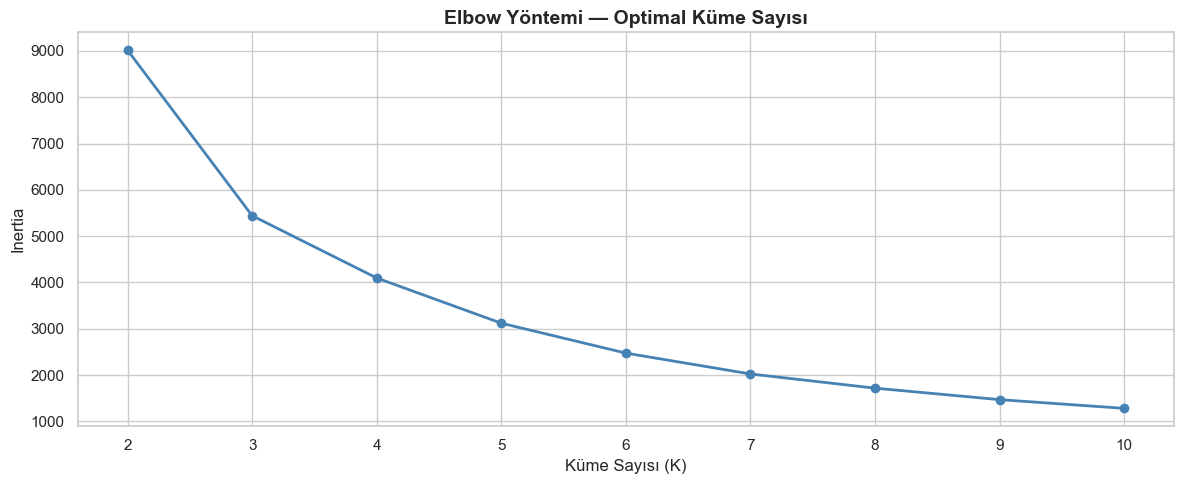

In [52]:
# Kaç cluster seçmeliyiz?
# Her K değeri için inertia (küme içi uzaklıkların karelerinin toplamı) hesaplıyoruz.
# İnertia K arttıkça düşer ama bir noktadan sonra kazanım azalır —
# bu "dirsek" noktası optimal K'yı gösterir.

inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(K_range, inertias, marker='o', linewidth=2, color='steelblue')
ax.set_title('Elbow Yöntemi — Optimal Küme Sayısı', fontsize=14, fontweight='bold')
ax.set_xlabel('Küme Sayısı (K)')
ax.set_ylabel('Inertia')
ax.set_xticks(K_range)
plt.tight_layout()
plt.show()

**Gözlem:** 
K=2→3 arasında inertia en sert düşüşü yaşıyor (~9000→5400).  
K=4'ten itibaren düşüş hızı belirgin biçimde yavaşlıyor.  
Elbow K=3-4 aralığında görünüyor — optimal K'yı  
silhouette score ile doğrulayacağız.

#### Silhouette Kontrolü

In [53]:
# Elbow'un gösterdiği K'yı silhouette score ile doğruluyoruz.
# Silhouette score: -1 ile 1 arasında, 1'e yakınsa kümeler iyi ayrışmış demek.
# Genellikle 0.4+ kabul edilebilir, 0.6+ iyi sayılır.

for k in [3, 4, 5]:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(rfm_scaled)
    sil = silhouette_score(rfm_scaled, lbl)
    print(f"K={k}  →  Silhouette Score: {sil:.4f}")

K=3  →  Silhouette Score: 0.5942
K=4  →  Silhouette Score: 0.6162
K=5  →  Silhouette Score: 0.6165


#### K-Means Uygulaması

In [54]:
# Elbow ve silhouette analizine dayanarak seçtiğimiz K ile modeli kuruyoruz.
# n_init=10: farklı başlangıç noktalarından 10 kez çalıştırıp en iyisini seçiyor.
# random_state=42: sonuçların tekrarlanabilir olması için.

K_OPTIMAL = 4 

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"K-Means tamamlandı. K={K_OPTIMAL}")
print("\nCluster başına müşteri sayısı:")
print(rfm['Cluster'].value_counts().sort_index())

K-Means tamamlandı. K=4

Cluster başına müşteri sayısı:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [55]:
# Her cluster'ın RFM ortalamalarına bakıyoruz.
# Bu tablo cluster'lara isim vermenin temel kaynağı.
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_summary['MusteriSayisi'] = rfm['Cluster'].value_counts().sort_index()
print(cluster_summary.to_string())

         Recency  Frequency   Monetary  MusteriSayisi
Cluster                                              
0          43.70       3.68    1353.63           3054
1         248.08       1.55     478.85           1067
2           7.38      82.54  127187.96             13
3          15.50      22.33   12690.50            204


**Cluster Yorumu**

| Cluster | Segment Adı | Recency | Frequency | Monetary | Müşteri Sayısı |
|---------|-------------|---------|-----------|----------|----------------|
| 2 | 🏆 VIP / Şampiyon | 7 gün | 82 fatura | £127,187 | 13 |
| 3 | ⭐ Sadık Müşteriler | 15 gün | 22 fatura | £12,690 | 204 |
| 0 | 🔄 Aktif / Potansiyel | 43 gün | 3 fatura | £1,353 | 3054 |
| 1 | 😴 Kaybedilen / Uyuyan | 248 gün | 1 fatura | £478 | 1067 |

**İş Perspektifinden Yorumlar:**

- **Cluster 2 (VIP):** Yalnızca 13 müşteri ancak olağanüstü yüksek 
  Frequency ve Monetary değerleriyle toptan alıcı profiline işaret ediyor.
  Bu grup kaybedilmemeli — öncelikli müşteri hizmetleri ve 
  kişiselleştirilmiş teklifler uygulanmalı.

- **Cluster 3 (Sadık):** 204 müşteri, düzenli ve yakın zamanlı alışveriş. 
  Upsell ve cross-sell kampanyaları için en verimli segment.

- **Cluster 0 (Aktif/Potansiyel):** En kalabalık grup (3054 müşteri). 
  Satın alma sıklığı düşük — hedefli kampanyalarla 
  Cluster 3'e dönüştürülmesi hedeflenmeli.

- **Cluster 1 (Kaybedilen):** Son alışveriş 248 gün önce. 
  Yeniden kazanım e-postası veya özel indirim kampanyası önerilir.

Upsell (Yukarı Satış) ve Cross-sell (Çapraz Satış), mevcut müşterilere daha fazla değer sunarak sepet ortalamasını ve toplam satış gelirini artırmayı hedefleyen iki temel pazarlama ve satış stratejisidir.
* Upsell, müşterinin satın almayı düşündüğü veya ilgilendiği bir ürünün daha gelişmiş, daha kaliteli, daha büyük veya üst modelini sunarak müşteriyi daha yüksek bir harcama yapmaya ikna etme stratejisidir. Burada amaç, müşteriye aynı ihtiyacı daha iyi karşılayacak daha pahalı bir alternatif sunmaktır.
* Cross-sell, müşterinin satın aldığı veya almayı planladığı ana ürünün yanına onu tamamlayan, onunla ilişkili veya entegre çalışan ek ürünler önerme stratejisidir. Burada amaç, tek bir ürünü yükseltmek değil, müşterinin sepetine farklı ama ilgili parçalar ekleterek ürün çeşitliliğini ve sepet tutarını büyütmektir.


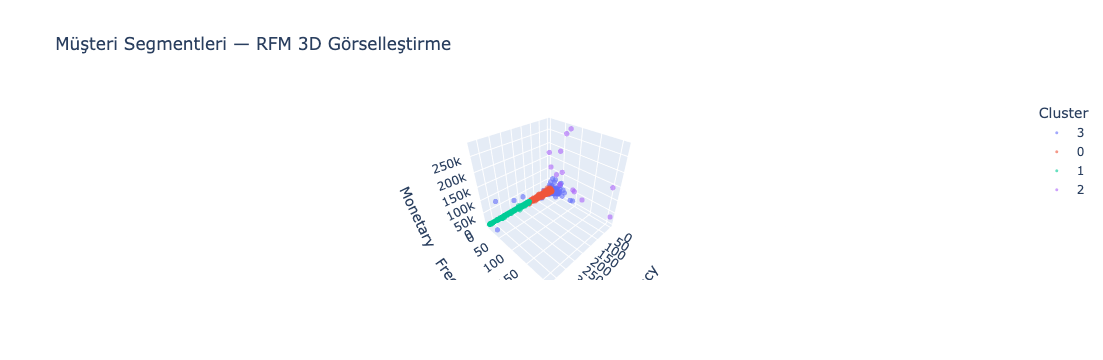

In [66]:
# Cluster'ları 3 boyutlu görselleştiriyoruz.
# Renk = cluster, eksenler = R, F, M
# Bu grafik segmentlerin gerçekten ayrıştığını gösteriyor.

import plotly.express as px

fig = px.scatter_3d(
    rfm,
    x='Recency', y='Frequency', z='Monetary',
    color=rfm['Cluster'].astype(str),
    title='Müşteri Segmentleri — RFM 3D Görselleştirme',
    labels={'color': 'Cluster'},
    opacity=0.6
)
fig.update_traces(marker=dict(size=3))
fig.show()

**📌 Araştırma Sorusu 3 — Cevap**

K-Means kümeleme sonucunda 4 anlamlı müşteri segmenti ortaya çıktı.
Silhouette score 0.6162 — gerçek dünya verisinde makul düzeyde 
iyi bir ayrışma.

En dikkat çekici bulgu: Yalnızca 13 müşteriden oluşan VIP segmenti
(Cluster 2), ortalama £127,187 harcamayla toptan alıcı profilini 
yansıtıyor. AS4 Pareto analiziyle de tutarlı: az sayıda müşteri 
gelirin büyük bölümünü oluşturuyor.

---
# Sonuç ve Yorumlar

In [76]:
# Projenin tüm sayısal bulgularını tek hücrede özetliyoruz.

print("=" * 55)
print("       PROJE BULGULARI — ÖZET")
print("=" * 55)

print("\n📦 VERİ SETİ")
print(f"  Ham veri          : 541,909 işlem")
print(f"  Temizlenmiş veri  : 392,692 işlem")
print(f"  Benzersiz müşteri : {rfm['CustomerID'].nunique():,}")
print(f"  Benzersiz ürün    : {df_clean['StockCode'].nunique():,}")
print(f"  Kapsanan dönem    : Ara 2010 – Ara 2011")

print("\n💰 GELİR ANALİZİ")
toplam = df_clean['TotalPrice'].sum()
print(f"  Toplam satış geliri : £{toplam:,.2f}")
print(f"  En yüksek aylık gelir: Kasım 2011 — £1,156,205")
print(f"  İngiltere gelir payı : %82.0")

print("\n🔄 İADE ANALİZİ (AS1)")
print(f"  Toplam iade işlemi  : 9,288")
print(f"  İade/Satış oranı    : %10.09")

print("\n📅 MEVSİMSELLİK (AS2)")
print(f"  En yoğun saat       : 12:00")
print(f"  Haftasonu işlem payı: Çok düşük (B2B profili)")
print(f"  Yıl sonu zirvesi    : Eylül–Kasım arası artış")

print("\n📊 PARETO (AS4)")
print(f""" Gelirin %80'ini oluşturan müşteri oranı: %26.0""")


print("\n👥 MÜŞTERİ SEGMENTASYONU (AS3)")
print(f"  Optimal K           : 4")
print(f"  Silhouette Score    : 0.6162")
for c, row in rfm.groupby('Cluster')[['Frequency','Monetary']].mean().iterrows():
    n = (rfm['Cluster'] == c).sum()
    print(f"  Cluster {c}           : {n:,} müşteri | "
          f"Ort. {row['Frequency']:.0f} fatura | £{row['Monetary']:,.0f}")
print("=" * 55)

       PROJE BULGULARI — ÖZET

📦 VERİ SETİ
  Ham veri          : 541,909 işlem
  Temizlenmiş veri  : 392,692 işlem
  Benzersiz müşteri : 4,338
  Benzersiz ürün    : 3,665
  Kapsanan dönem    : Ara 2010 – Ara 2011

💰 GELİR ANALİZİ
  Toplam satış geliri : £8,887,208.89
  En yüksek aylık gelir: Kasım 2011 — £1,156,205
  İngiltere gelir payı : %82.0

🔄 İADE ANALİZİ (AS1)
  Toplam iade işlemi  : 9,288
  İade/Satış oranı    : %10.09

📅 MEVSİMSELLİK (AS2)
  En yoğun saat       : 12:00
  Haftasonu işlem payı: Çok düşük (B2B profili)
  Yıl sonu zirvesi    : Eylül–Kasım arası artış

📊 PARETO (AS4)
 Gelirin %80'ini oluşturan müşteri oranı: %26.0

👥 MÜŞTERİ SEGMENTASYONU (AS3)
  Optimal K           : 4
  Silhouette Score    : 0.6162
  Cluster 0           : 3,054 müşteri | Ort. 4 fatura | £1,354
  Cluster 1           : 1,067 müşteri | Ort. 2 fatura | £479
  Cluster 2           : 13 müşteri | Ort. 83 fatura | £127,188
  Cluster 3           : 204 müşteri | Ort. 22 fatura | £12,691


## 🎯 Genel Değerlendirme

Bu analiz, bir İngiliz online hediyecilik mağazasının 2010–2011 
işlem verisinden aşağıdaki bulgulara ulaştı:

**1. İşletme Profili**  
Müşteri tabanının büyük çoğunluğu toptan alıcılardan (B2B) oluşuyor. 
Bunu destekleyen 3 kanıt: haftasonu işlem yokluğu, 
iş saatleri yoğunluğu ve 13 VIP müşterinin olağanüstü 
yüksek harcama değerleri.

**2. Mevsimsellik**  
Yılın son çeyreğinde (Eylül–Kasım) belirgin satış artışı. 
Kasım 2011, tüm dönemin en yüksek gelirini
oluşturuyor. Mağaza bu döneme özel stok ve kampanya planlaması yapmalı.

**3. Müşteri Konsantrasyonu**  
Pareto analizi ve RFM segmentasyonu tutarlı bir bulguya işaret ediyor: 
küçük bir müşteri grubu gelirin büyük bölümünü oluşturuyor. 
Bu grup için müşteri kaybı riski yönetimi kritik önem taşıyor.

**4. Büyüme Fırsatı**  
3054 müşteriden oluşan Aktif/Potansiyel segment 
(düşük Frequency, orta Monetary) doğru kampanyalarla 
Sadık segment'e dönüştürülebilir.

---

## ⚠️ Sınırlamalar

- CustomerID eksikliği nedeniyle işlemlerin ~%25'i müşteri 
  analizinin dışında kaldı.
- Veri seti tek bir yılı kapsıyor; uzun vadeli trend 
  yorumu yapmak mümkün değil.
- Ürün kategorisi bilgisi olmadığından kategori bazlı 
  analiz yapılamadı.
- K-Means küre şeklinde kümeler varsayar; 
  farklı geometrilerde DBSCAN daha uygun olabilirdi.

---

## 📚 Öğrenilenler

**Teknik:**  
- Gerçek veri asla temiz gelmez — temizleme adımı 
  toplam sürenin önemli bir bölümünü aldı.
- RFM, iş yorumu güçlü ve hesaplanması nispeten 
  basit bir özellik mühendisliği örneği.
- Silhouette score model seçiminde elbow yöntemini 
  tamamlayan önemli bir araç.

**Süreç:**  
- Vibe coding iş akışı (Claude + Jupyter) iteratif 
  çalışmayı kolaylaştırdı; her adımda üretilen kodu 
  anlayıp doğrulamak süreci daha verimli kıldı.